In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.insert(0, parent_dir)

In [2]:
from modelo import entrenar_modelo_rf
from generador import generar_horarios
from validacion import verificar_traslapes
from exportador import exportar_horarios

import json

In [3]:
CONFIGURACION = "../config.json"

In [4]:
# Cargar configuración
with open(CONFIGURACION, "r", encoding="utf-8") as f:
    config_json = json.load(f)

## generar

In [5]:
df_entrenamiento = generar_horarios(config_json, num_grupos=15)
df_entrenamiento

,Grupo,Materia,Profesor,Aula,Modalidad,Día,Bloque
0,AM01,Idoneidad docente en el marco del modelo educa...,Jorge Ramírez Sánchez,A1,M,Martes,13:30 a 15:00
1,AM01,Academia de exploración y comprensión del mund...,Carmen Pérez Aguilar,A1,M,Lunes,12:00 a 13:30
2,AM01,Artes,Claudia Cecilia Hendrix Galarza,A1,M,Miércoles,13:30 a 15:00
3,AM01,Ámbito de autonomía curricular,Gabriela Garduño González,A1,M,Miércoles,12:00 a 13:30
4,AM01,Pensamiento matemático,Lucía Ramírez Fausto,A1,M,Miércoles,10:30 a 12:00
...,...,...,...,...,...,...,...
155,BS29,Competencias académicas y su aplicación profes...,Renato Escalona Durán,A9,S,Sábado,12:00 a 13:30
156,BS30,Organización de la enseñanza,María Teresa Dantés Ontiveros Cervantes,A10,S,Sábado,12:00 a 13:30
157,BS30,Educación socioemocional,Sheribeth Duarte Yunt,A10,S,Sábado,09:00 a 10:30
158,BS30,Técnicas digitales para la enseñanza,Enedina Sánchez Rubalcava,A10,S,Sábado,13:30 a 15:00


## entrenar_modelo_rf

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

In [7]:
df = df_entrenamiento

le_dict = {col: LabelEncoder() for col in ["Grupo", "Día", "Bloque", "Aula", "Profesor", "Materia"]}
for col, le in le_dict.items():
    df[col + "_enc"] = le.fit_transform(df[col])
df["Valido"] = 1

# Segun entiendo, se destina un 20% del conjunto de datos para ser marcado
# como inválido, pero no hay algo que indique el "criterio de invalidación".
invalids = df.sample(frac=0.2).copy()
invalids["Aula_enc"] = (invalids["Aula_enc"] + 1) % df["Aula_enc"].nunique()
invalids["Valido"] = 0
combined = pd.concat([df, invalids])
X = combined[[col + "_enc" for col in le_dict]]
y = combined["Valido"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = rf.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7948717948717948


In [12]:
# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

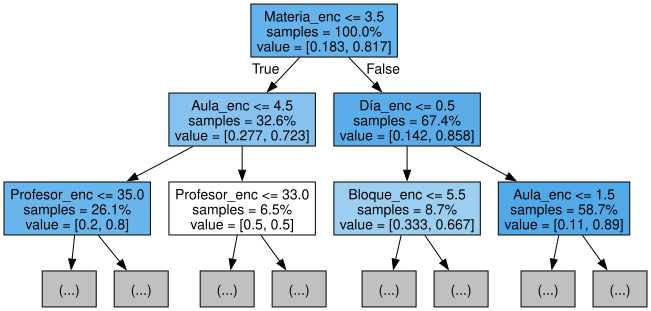

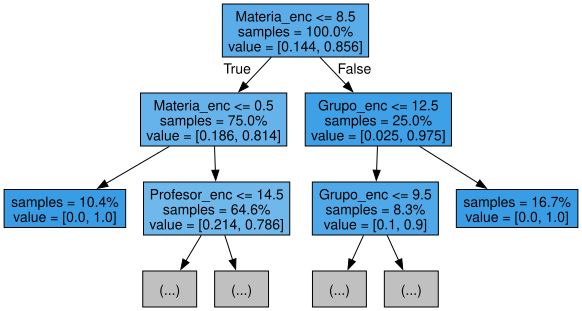

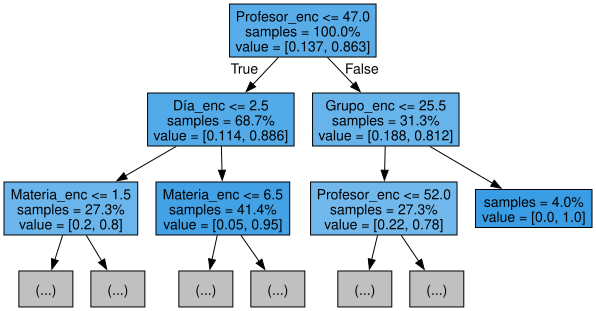

In [13]:
# Export the first three decision trees from the forest

for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from random import randint

In [15]:
param_dist = {'n_estimators': [randint(10,500)],
              'max_depth': [randint(1,20)]}

# Create a random forest classifier
rf2 = RandomForestClassifier()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf2, 
                                 param_distributions = param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

/Users/lalo/Applications/Miniconda3/envs/jcsra/lib/python3.11/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=5. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [14], 'n_estimators': [283]}"
,n_iter,5
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [17]:
rf3 = RandomForestClassifier(max_depth=14, n_estimators=283)
rf3.fit(X_train, y_train)
y_pred = rf3.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7692307692307693


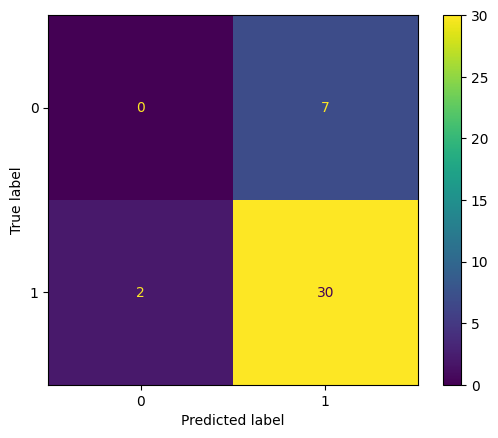

In [18]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [19]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.7692307692307693
Precision: 0.8108108108108109
Recall: 0.9375


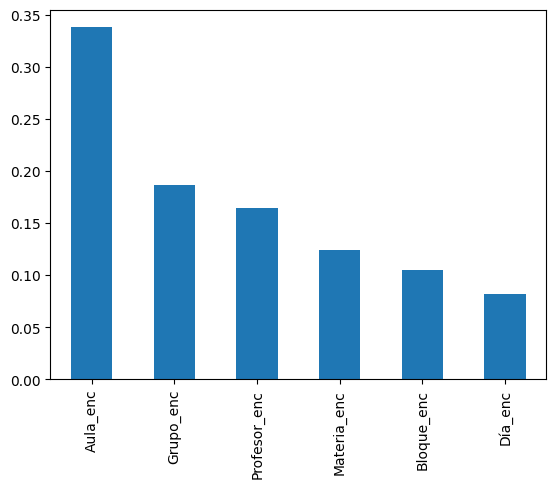

In [20]:
feature_importances = pd.Series(rf3.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_importances.plot.bar();